In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\hp\LOAN_DEFAULT_ANALYSIS\Cleaned_csv_file\Loan_default_clean.csv")

C:\Users\hp\AppData\Local\Temp\ipykernel_14896\4216590154.py:4: DtypeWarning: Columns (0: next_pymnt_d) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\hp\LOAN_DEFAULT_ANALYSIS\Cleaned_csv_file\Loan_default_clean.csv")


Credit Profile

This examines the borrower's existing credit history and financial position.

Debt-to-income ratio

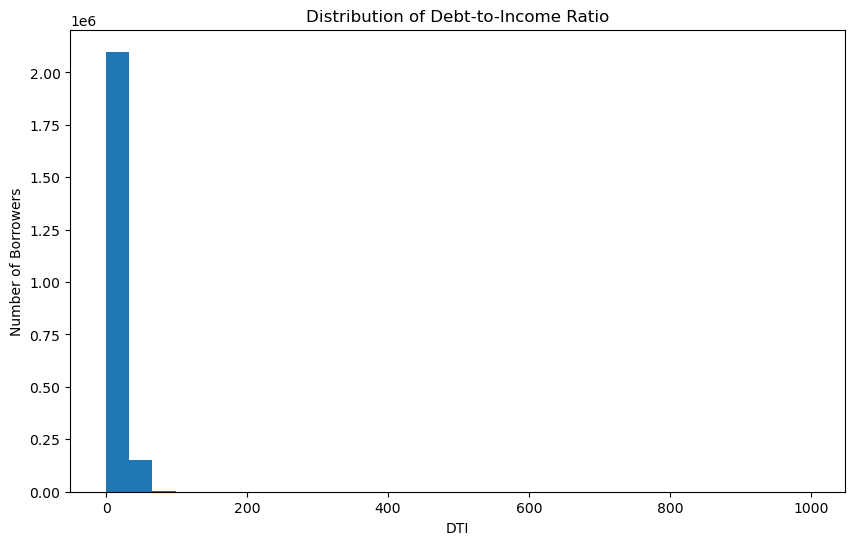

In [3]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["dti"].dropna(),
    bins=30
)

plt.title("Distribution of Debt-to-Income Ratio")
plt.xlabel("DTI")
plt.ylabel("Number of Borrowers")

plt.show()

In [4]:
dti = df["dti"].dropna()

print("Minimum:", dti.min())
print("Maximum:", dti.max())
print("Number of values:", len(dti))

Minimum: -1.0
Maximum: 999.0
Number of values: 2258957


In [5]:
df["dti"].value_counts().sort_index().head(20)

dti
-1.00       2
 0.00    1732
 0.01      22
 0.02      35
 0.03      19
 0.04      16
 0.05      20
 0.06      32
 0.07      27
 0.08      30
 0.09      24
 0.10      33
 0.11      33
 0.12      33
 0.13      46
 0.14      42
 0.15      38
 0.16      50
 0.17      46
 0.18      47
Name: count, dtype: int64

In [6]:
df["dti"].value_counts().sort_index().tail(20)

dti
822.00      1
831.97      1
844.80      1
847.22      1
851.20      1
855.20      1
879.55      1
883.61      1
886.77      1
893.10      1
917.87      1
941.46      1
942.17      1
962.83      1
973.17      1
991.57      1
994.40      1
995.17      1
995.60      1
999.00    135
Name: count, dtype: int64

In [7]:
print("Negative values:", (df["dti"] < 0).sum())
print("999 values:", (df["dti"] == 999).sum())

Negative values: 2
999 values: 135


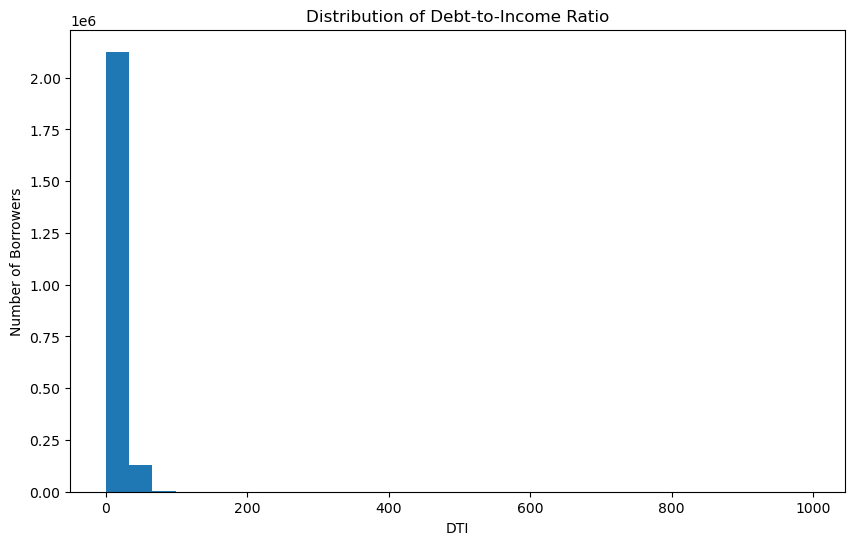

In [8]:
dti_clean = df.loc[~df["dti"].isin([-1, 999]), "dti"].dropna()

plt.figure(figsize=(10, 6))
plt.hist(dti_clean, bins=30)

plt.title("Distribution of Debt-to-Income Ratio")
plt.xlabel("DTI")
plt.ylabel("Number of Borrowers")

plt.show()

In [9]:
df[df["dti"] == 999][["loan_status", "purpose", "verification_status"]].head()

,loan_status,purpose,verification_status
10817,Current,debt_consolidation,Not Verified
26858,Current,credit_card,Source Verified
44220,Current,debt_consolidation,Not Verified
46557,Current,debt_consolidation,Not Verified
56594,Current,credit_card,Verified


In [10]:
df["dti"].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])

count    2.258957e+06
mean     1.882420e+01
std      1.418333e+01
min     -1.000000e+00
1%       1.720000e+00
5%       4.940000e+00
25%      1.189000e+01
50%      1.784000e+01
75%      2.449000e+01
95%      3.388000e+01
99%      4.271000e+01
max      9.990000e+02
Name: dti, dtype: float64

In [11]:
print("DTI > 100:", (df["dti"] > 100).sum())
print("DTI > 200:", (df["dti"] > 200).sum())
print("DTI > 500:", (df["dti"] > 500).sum())
print("DTI > 800:", (df["dti"] > 800).sum())

DTI > 100: 2561
DTI > 200: 836
DTI > 500: 264
DTI > 800: 158


In [12]:
df.loc[df["dti"] > 100, "dti"].describe()

count    2561.000000
mean      242.775490
std       226.038521
min       100.040000
25%       117.300000
50%       149.650000
75%       245.490000
max       999.000000
Name: dti, dtype: float64

In [13]:
df["dti"].isna().sum()

np.int64(1711)

In [14]:
print("Missing:", df["dti"].isna().sum())
print("Missing %:", df["dti"].isna().mean() * 100)

Missing: 1711
Missing %: 0.07568559381563325


Revolving credit utilization

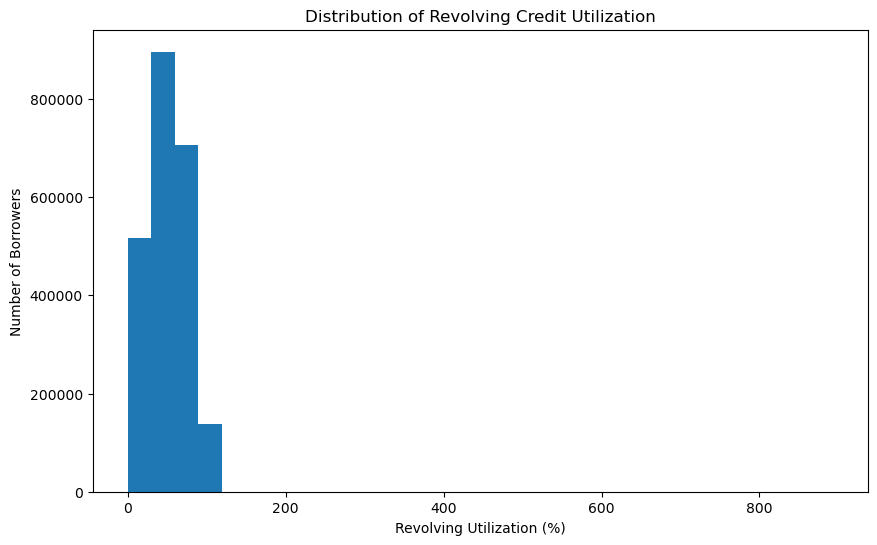

In [15]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["revol_util"].dropna(),
    bins=30
)

plt.title("Distribution of Revolving Credit Utilization")
plt.xlabel("Revolving Utilization (%)")
plt.ylabel("Number of Borrowers")

plt.show()

Number of open accounts

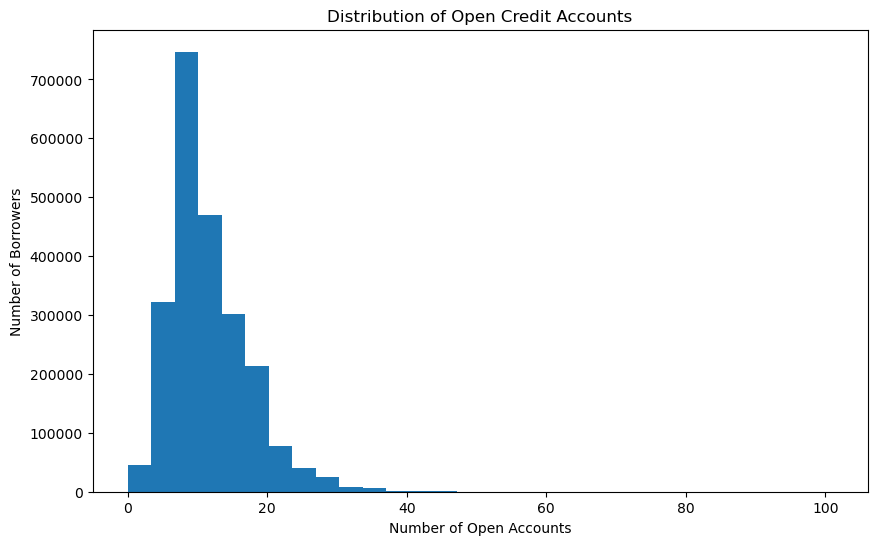

In [16]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["open_acc"].dropna(),
    bins=30
)

plt.title("Distribution of Open Credit Accounts")
plt.xlabel("Number of Open Accounts")
plt.ylabel("Number of Borrowers")

plt.show()

Delinquencies

In [17]:
df["delinq_2yrs"].value_counts().sort_index()

delinq_2yrs
0.0     1839108
1.0      281353
2.0       81289
3.0       29542
4.0       13179
5.0        6599
6.0        3717
7.0        2062
8.0        1223
9.0         818
10.0        556
11.0        363
12.0        263
13.0        165
14.0        120
15.0         87
16.0         55
17.0         30
18.0         30
19.0         23
20.0         17
21.0         12
22.0          5
23.0          2
24.0          4
25.0          2
26.0          3
27.0          1
28.0          1
29.0          2
30.0          2
32.0          1
35.0          1
36.0          1
39.0          1
42.0          1
58.0          1
Name: count, dtype: int64

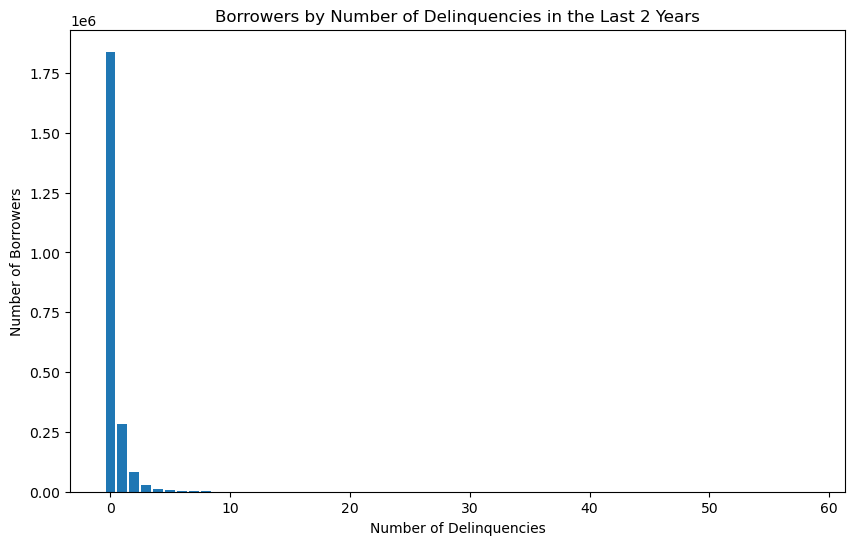

In [19]:
delinq_counts = df["delinq_2yrs"].value_counts().sort_index()

plt.figure(figsize=(10, 6))

plt.bar(
    delinq_counts.index,
    delinq_counts.values
)

plt.title("Borrowers by Number of Delinquencies in the Last 2 Years")
plt.xlabel("Number of Delinquencies")
plt.ylabel("Number of Borrowers")

plt.show()

Public records

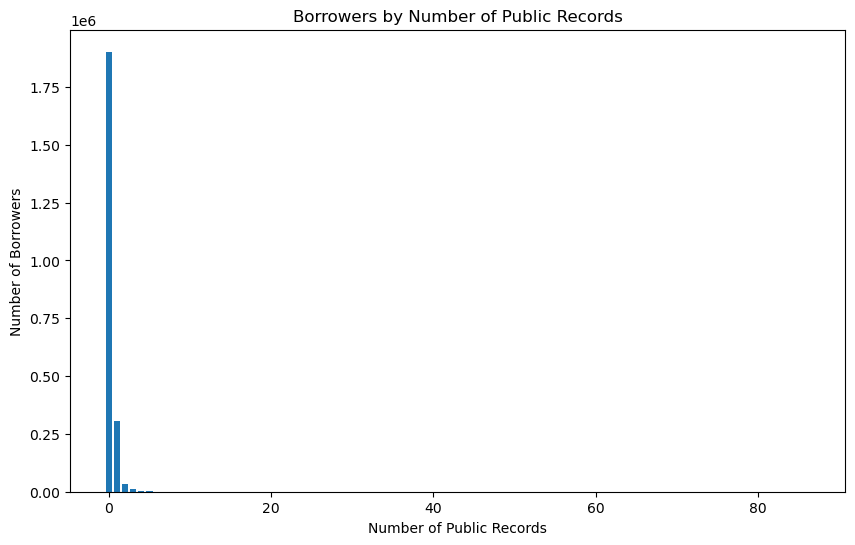

In [20]:
pubrec_counts = df["pub_rec"].value_counts().sort_index()

plt.figure(figsize=(10, 6))

plt.bar(
    pubrec_counts.index,
    pubrec_counts.values
)

plt.title("Borrowers by Number of Public Records")
plt.xlabel("Number of Public Records")
plt.ylabel("Number of Borrowers")

plt.show()

Credit account distribution

In [22]:
credit_variables = [
    "open_acc",
    "total_acc",
    "revol_bal",
    "revol_util",
    "delinq_2yrs",
    "inq_last_6mths",
    "pub_rec"
]

df[credit_variables].describe()

,open_acc,total_acc,revol_bal,revol_util,delinq_2yrs,inq_last_6mths,pub_rec
count,2.260639e+06,2.260639e+06,2.260668e+06,2.258866e+06,2.260639e+06,2.260638e+06,2.260639e+06
mean,1.161240e+01,2.416255e+01,1.665846e+04,5.033770e+01,3.068792e-01,5.768354e-01,1.975278e-01
std,5.640861e+00,1.198753e+01,2.294831e+04,2.471307e+01,8.672303e-01,8.859632e-01,5.705150e-01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.000000e+00,1.500000e+01,5.950000e+03,3.150000e+01,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.100000e+01,2.200000e+01,1.132400e+04,5.030000e+01,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.400000e+01,3.100000e+01,2.024600e+04,6.940000e+01,0.000000e+00,1.000000e+00,0.000000e+00
max,1.010000e+02,1.760000e+02,2.904836e+06,8.923000e+02,5.800000e+01,3.300000e+01,8.600000e+01
